# Libs

In [27]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    train_test_split, TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.metrics import (
    f1_score, precision_score, recall_score, balanced_accuracy_score,
    roc_curve, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute

from scipy.stats import kurtosis

from utils.futurai_ppd import drop_transitorio_desligado

# Import dataset

In [2]:
base_name = 'Depurador 762-28-006 - Cozimento'
timestamp = "Timestamp"

df_dataset = pd.read_csv('data/' + base_name + '.csv', sep=";", decimal=".", encoding="utf-8-sig")
df_dataset[timestamp] = pd.to_datetime(df_dataset[timestamp], format="%Y-%m-%d %H:%M:%S")

## Drop columns with NaN values, constant values or irrelevant to the analysis
df_dataset.drop(columns=["762H0336.PV", "762H0342.PV", "762N0015.SP", "762P0013.SP", "762-34-073.CR", "762N0015.OP"], inplace=True, errors='ignore')

df_dataset.dropna(inplace=True)

print(f"Dataset shape: {df_dataset.shape}")

list_variables = df_dataset.columns.tolist()
df_dataset.head()

Dataset shape: (901550, 68)


,Timestamp,762-28-006.CR,762-34-071.CR,762-34-071.PV,762-34-071_TRQ.PV,762F0014.OP,762F0014.PV,762F0014.SP,762F0036.OP,762F0036.PV,...,761X2008.PV,761T0074.PV,761X2009.PV,761X2010.PV,761X2011.PV,761L0132.PV,761F0098.PV,761F0148.PV,761F0099.PV,761A0068.PV
0,2024-01-01 00:00:00,76.562500,80.473549,871.057129,117.086792,54.741051,1645.879761,1630,40.641499,99.093948,...,1.398378,127.075958,4.468976,4.196648,1.924856,79.570648,60.192554,225.350510,445.207458,14.466122
1,2024-01-01 00:01:00,77.083336,80.111168,869.423401,115.429688,54.239021,1657.596558,1630,42.854092,96.310211,...,1.398688,127.174057,4.480108,4.204310,1.925459,79.572044,64.455177,228.029800,453.648071,14.823081
2,2024-01-01 00:02:00,77.083336,80.067627,865.568543,114.445496,55.494858,1590.257446,1630,40.640480,96.673821,...,1.396329,127.214562,4.499777,4.206403,1.910060,79.633400,63.457355,225.979981,451.673828,14.366011
3,2024-01-01 00:03:00,76.704544,80.319565,867.364502,115.686035,54.277168,1627.854004,1630,42.147587,96.626137,...,1.396818,127.108513,4.508104,4.137139,1.886652,79.633400,63.340488,223.164856,451.416321,14.348478
4,2024-01-01 00:04:00,73.697914,80.373352,872.399902,116.816711,54.725792,1682.703857,1630,39.192886,101.788269,...,1.399590,127.202469,4.516319,4.165586,1.868354,79.591568,62.128384,226.399628,447.897003,14.231587


## Remove periods Off

In [3]:
pre_process = []
pp_var_ref_desligado = "762-28-006.CR"
pp_valor_ref_desligado = 5
pp_tempo_ref_desligado = 0
pp_pre_corte_transitorio = 30
pp_pos_corte_transitorio = 30
pre_process.append(  
{
   "after_cut": pp_pos_corte_transitorio,
   "interval_off": pp_tempo_ref_desligado,
   "limit_off": pp_valor_ref_desligado,
   "pre_cut": pp_pre_corte_transitorio,
   "variable_off": pp_var_ref_desligado
  })

for pro in pre_process:
    df_dataset,_,_ = drop_transitorio_desligado(df_dataset,pro["variable_off"],pro["limit_off"],pro["interval_off"],timestamp,pre_corte=pro["pre_cut"],pos_corte=pro["after_cut"])
print(f"Dataset shape: {df_dataset.shape}")
df_dataset.head()

Dataset shape: (812201, 68)


,Timestamp,762-28-006.CR,762-34-071.CR,762-34-071.PV,762-34-071_TRQ.PV,762F0014.OP,762F0014.PV,762F0014.SP,762F0036.OP,762F0036.PV,...,761X2008.PV,761T0074.PV,761X2009.PV,761X2010.PV,761X2011.PV,761L0132.PV,761F0098.PV,761F0148.PV,761F0099.PV,761A0068.PV
0,2024-01-01 00:00:00,76.562500,80.473549,871.057129,117.086792,54.741051,1645.879761,1630,40.641499,99.093948,...,1.398378,127.075958,4.468976,4.196648,1.924856,79.570648,60.192554,225.350510,445.207458,14.466122
1,2024-01-01 00:01:00,77.083336,80.111168,869.423401,115.429688,54.239021,1657.596558,1630,42.854092,96.310211,...,1.398688,127.174057,4.480108,4.204310,1.925459,79.572044,64.455177,228.029800,453.648071,14.823081
2,2024-01-01 00:02:00,77.083336,80.067627,865.568543,114.445496,55.494858,1590.257446,1630,40.640480,96.673821,...,1.396329,127.214562,4.499777,4.206403,1.910060,79.633400,63.457355,225.979981,451.673828,14.366011
3,2024-01-01 00:03:00,76.704544,80.319565,867.364502,115.686035,54.277168,1627.854004,1630,42.147587,96.626137,...,1.396818,127.108513,4.508104,4.137139,1.886652,79.633400,63.340488,223.164856,451.416321,14.348478
4,2024-01-01 00:04:00,73.697914,80.373352,872.399902,116.816711,54.725792,1682.703857,1630,39.192886,101.788269,...,1.399590,127.202469,4.516319,4.165586,1.868354,79.591568,62.128384,226.399628,447.897003,14.231587


## Create label for anomaly

In [4]:
periodos_de_Falhas = [
    (pd.Timestamp('2024-05-03 11:00:00'), pd.Timestamp('2024-05-03 11:35:00')),
    (pd.Timestamp('2024-06-25 17:20:00'), pd.Timestamp('2024-08-02 14:00:00')),
    (pd.Timestamp('2024-10-19 10:40:00'), pd.Timestamp('2024-10-19 10:50:00')),
    (pd.Timestamp('2024-10-19 10:40:00'), pd.Timestamp('2024-10-19 10:50:00')),
    (pd.Timestamp('2024-10-21 12:00:00'), pd.Timestamp('2024-10-22 00:35:00')),
    (pd.Timestamp('2024-10-24 03:10:00'), pd.Timestamp('2024-10-27 00:00:00')),
    (pd.Timestamp('2024-11-14 06:40:00'), pd.Timestamp('2024-11-14 19:45:00')),
    (pd.Timestamp('2024-11-25 21:45:00'), pd.Timestamp('2024-11-25 22:03:00')),
    (pd.Timestamp('2024-11-27 15:00:00'), pd.Timestamp('2024-11-27 15:07:00')),
    (pd.Timestamp('2024-11-27 16:04:00'), pd.Timestamp('2024-11-27 16:11:00')),
    (pd.Timestamp('2024-11-30 13:30:00'), pd.Timestamp('2024-11-30 15:52:00')),
    (pd.Timestamp('2024-12-09 20:30:00'), pd.Timestamp('2024-12-11 07:00:00')),
    (pd.Timestamp('2024-12-12 20:45:00'), pd.Timestamp('2024-12-12 21:15:00')),
    (pd.Timestamp('2025-03-05 15:17:00'), pd.Timestamp('2025-03-05 15:24:00')),
    (pd.Timestamp('2025-03-15 18:30:00'), pd.Timestamp('2025-03-15 19:15:00')),
    (pd.Timestamp('2025-03-18 11:40:00'), pd.Timestamp('2025-03-18 20:00:00')),
    (pd.Timestamp('2025-06-11 17:25:00'), pd.Timestamp('2025-06-11 17:50:00')),
    (pd.Timestamp('2025-06-16 15:20:00'), pd.Timestamp('2025-06-17 07:38:00')),
]

df_dataset['Falhas'] = 0
for inicio, fim in periodos_de_Falhas:
    df_dataset.loc[(df_dataset[timestamp] >= inicio) & (df_dataset[timestamp] <= fim), 'Falhas'] = 1
df_dataset.head()

,Timestamp,762-28-006.CR,762-34-071.CR,762-34-071.PV,762-34-071_TRQ.PV,762F0014.OP,762F0014.PV,762F0014.SP,762F0036.OP,762F0036.PV,...,761T0074.PV,761X2009.PV,761X2010.PV,761X2011.PV,761L0132.PV,761F0098.PV,761F0148.PV,761F0099.PV,761A0068.PV,Falhas
0,2024-01-01 00:00:00,76.562500,80.473549,871.057129,117.086792,54.741051,1645.879761,1630,40.641499,99.093948,...,127.075958,4.468976,4.196648,1.924856,79.570648,60.192554,225.350510,445.207458,14.466122,0
1,2024-01-01 00:01:00,77.083336,80.111168,869.423401,115.429688,54.239021,1657.596558,1630,42.854092,96.310211,...,127.174057,4.480108,4.204310,1.925459,79.572044,64.455177,228.029800,453.648071,14.823081,0
2,2024-01-01 00:02:00,77.083336,80.067627,865.568543,114.445496,55.494858,1590.257446,1630,40.640480,96.673821,...,127.214562,4.499777,4.206403,1.910060,79.633400,63.457355,225.979981,451.673828,14.366011,0
3,2024-01-01 00:03:00,76.704544,80.319565,867.364502,115.686035,54.277168,1627.854004,1630,42.147587,96.626137,...,127.108513,4.508104,4.137139,1.886652,79.633400,63.340488,223.164856,451.416321,14.348478,0
4,2024-01-01 00:04:00,73.697914,80.373352,872.399902,116.816711,54.725792,1682.703857,1630,39.192886,101.788269,...,127.202469,4.516319,4.165586,1.868354,79.591568,62.128384,226.399628,447.897003,14.231587,0


## Import TAGs and descriptions

In [ ]:
df_subsistema = pd.read_csv('data/'+ base_name + '_subsistema.csv', sep=";", decimal=".", encoding="utf-8-sig")
df_subsistema

## Plot variables

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_dataset['Timestamp'],
    y=df_dataset["762P0034.PV"],
    mode='lines',
    name='762P0034.PV',
    line=dict(color='black')
))

fig.add_trace(go.Scatter(
    x=df_dataset['Timestamp'],
    y=df_dataset["Falhas"],
    mode='lines',
    name='Falhas',
    line=dict(color='red')
))

fig.update_layout(
    template='plotly_white',
    hovermode='x unified'
)
fig.show()

## Train Test Split

## Train

In [10]:
start_date = pd.to_datetime("2024-01-01 00:00:00")
end_date = pd.to_datetime("2025-03-12 09:25:00")
mask = (df_dataset[timestamp] >= start_date) & (df_dataset[timestamp] <= end_date)
df_train = df_dataset.loc[mask]

df_train.sort_values(by=[timestamp],inplace=True)
print(df_train.shape)
print("Falhas Train:",df_train[df_train["Falhas"]==1].shape[0])
print("Normal Train:",df_train[df_train["Falhas"]==0].shape[0])

(570825, 69)
Falhas Train: 62252
Normal Train: 508573


## Test

In [11]:
start_date = pd.to_datetime("2025-03-14 07:54:00")
end_date = pd.to_datetime("2025-10-30 00:00:00")
mask = (df_dataset[timestamp] >= start_date) & (df_dataset[timestamp] <= end_date)
df_test = df_dataset.loc[mask]

df_test.sort_values(by=[timestamp],inplace=True)
print(df_test.shape)
print("Falhas Train:",df_test[df_test["Falhas"]==1].shape[0])
print("Normal Train:",df_test[df_test["Falhas"]==0].shape[0])

(241376, 69)
Falhas Train: 1552
Normal Train: 239824


## Feature extraction

### Feature Extraction with tsfresh

#### Train data

In [ ]:
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import EfficientFCParameters

df_train.set_index(timestamp, inplace=True)

WINDOW_LENGTH = pd.Timedelta('60min')
STEP_SIZE = pd.Timedelta('30min')

windowed_dfs = []
start_time = df_train.index.min()
end_time = df_train.index.max()
window_starts = pd.date_range(start=start_time, end=end_time - WINDOW_LENGTH, freq=STEP_SIZE)

for i, start in enumerate(window_starts):
    end = start + WINDOW_LENGTH
    window_slice = df_train.loc[start:end].copy()
    window_slice['window_id'] = i
    windowed_dfs.append(window_slice)
    
df_windowed = pd.concat(windowed_dfs)

y_labels = (df_windowed.groupby("window_id")["Falhas"].mean() > 0.5).astype(int)

print("Distribuição dos rótulos das janelas:", y_labels.value_counts().to_dict())
print("-" * 50)

df_features_only = df_windowed.drop(columns=['Falhas'])

# Converte o DataFrame para o formato "longo" exigido pela tsfresh
df_long = df_features_only.reset_index().melt(
    id_vars=['window_id', timestamp], 
    var_name='kind',
    value_name='value'
)

print("Extraindo características com tsfresh...")

X_features_train = extract_features(
    df_long,
    column_id='window_id',
    column_sort=timestamp,
    column_kind='kind',
    column_value='value',
    default_fc_parameters=EfficientFCParameters(),
    n_jobs=1
)

print("Realizando imputação de valores ausentes/infinitos...")
X_features_train = impute(X_features_train)
y_features_train = y_labels.loc[X_features_train.index]

print("\nProcesso concluído!")
print(f"Formato final do DataFrame de características (X): {X_features_train.shape}")
print(f"Formato final da Series de rótulos (y): {y_features_train.shape}")

#### Test data

In [ ]:
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute

df_test.set_index(timestamp, inplace=True)

WINDOW_LENGTH = pd.Timedelta('60min')
STEP_SIZE = pd.Timedelta('30min')

windowed_dfs = []
start_time = df_test.index.min()
end_time = df_test.index.max()
window_starts = pd.date_range(start=start_time, end=end_time - WINDOW_LENGTH, freq=STEP_SIZE)

for i, start in enumerate(window_starts):
    end = start + WINDOW_LENGTH
    window_slice = df_test.loc[start:end].copy()
    window_slice['window_id'] = i
    windowed_dfs.append(window_slice)
    
df_windowed = pd.concat(windowed_dfs)

y_labels = (df_windowed.groupby("window_id")["Falhas"].mean() > 0.5).astype(int)

print("Distribuição dos rótulos das janelas:", y_labels.value_counts().to_dict())
print("-" * 50)

df_features_only = df_windowed.drop(columns=['Falhas'])

# Converte o DataFrame para o formato "longo" exigido pela tsfresh
df_long = df_features_only.reset_index().melt(
    id_vars=['window_id', timestamp], 
    var_name='kind',
    value_name='value'
)

print("Extraindo características com tsfresh...")

X_features_test = extract_features(
    df_long,
    column_id='window_id',
    column_sort=timestamp,
    column_kind='kind',
    column_value='value',
    default_fc_parameters=EfficientFCParameters(),
    n_jobs=1
)

print("Realizando imputação de valores ausentes/infinitos...")
X_features_test = impute(X_features_test)
y_features_test = y_labels.loc[X_features_train.index]

print("\nProcesso concluído!")
print(f"Formato final do DataFrame de características (X): {X_features_test.shape}")
print(f"Formato final da Series de rótulos (y): {y_features_test.shape}")

### Feature Extraction

#### Functions to extract features

In [8]:
def safe_autocorr(s, lag=1):
    """
    Calcula a autocorrelação de forma segura.
    Retorna 0.0 se a série tiver variância zero (constante) ou se ocorrer um erro.
    """
    try:
        # A autocorrelação é NaN para séries constantes.
        if s.var() == 0:
            return 0.0
        autocorr_val = s.autocorr(lag=lag)
        # s.autocorr() ainda pode retornar NaN em alguns casos extremos.
        return 0.0 if pd.isna(autocorr_val) else autocorr_val
    except Exception:
        return 0.0

def features_from_window(g):
    """
    Extrai features estatísticas de uma janela de dados.
    Qualquer valor NaN resultante dos cálculos é substituído por 0.0.
    """
    out = {}
    for col in g.columns:
        s = g[col].dropna()
        prefix = col
        
        # Lista de nomes das features para facilitar a iteração
        feature_names = [
            "mean", "std", "var", "min", "max", "median", "skew", "kurtosis",
            "q25", "q75", "iqr", "amplitude", "energy",
            "autocorr_lag1", "autocorr_lag2", "coeff_var"
        ]

        # Se a série (após remover NaNs) estiver vazia, preenche todas as features com 0.0
        if s.empty:
            for name in feature_names:
                out[f"{prefix}_{name}"] = 0.0
            continue

        # --- Cálculos das features para séries não vazias ---
        arr = s.values
        
        s_mean = s.mean()
        s_std = s.std()
        s_var = s.var()
        s_min = s.min()
        s_max = s.max()
        
        # Dicionário para armazenar as features da coluna atual
        col_feats = {
            f"{prefix}_mean": s_mean,
            f"{prefix}_std": s_std,
            f"{prefix}_var": s_var,
            f"{prefix}_min": s_min,
            f"{prefix}_max": s_max,
            f"{prefix}_median": s.median(),
            f"{prefix}_skew": s.skew(),
            f"{prefix}_kurtosis": float(kurtosis(arr, fisher=True)),
            f"{prefix}_q25": np.percentile(arr, 25),
            f"{prefix}_q75": np.percentile(arr, 75),
            f"{prefix}_energy": np.sum(arr ** 2)
        }
        
        # Features derivadas
        col_feats[f"{prefix}_iqr"] = col_feats[f"{prefix}_q75"] - col_feats[f"{prefix}_q25"]
        col_feats[f"{prefix}_amplitude"] = s_max - s_min
        
        # Autocorrelação segura
        col_feats[f"{prefix}_autocorr_lag1"] = safe_autocorr(s, lag=1)
        col_feats[f"{prefix}_autocorr_lag2"] = safe_autocorr(s, lag=2)
        
        # Coeficiente de variação
        col_feats[f"{prefix}_coeff_var"] = (s_std / s_mean) if s_mean != 0 else 0.0
            
        # --- Limpeza Final ---
        # Garante que nenhum NaN seja retornado (ex: std() com um único ponto de dados)
        for name in feature_names:
            key = f"{prefix}_{name}"
            # Usa .get() para evitar KeyError caso a feature não tenha sido calculada
            if pd.isna(col_feats.get(key)):
                 col_feats[key] = 0.0
        
        out.update(col_feats)

    return pd.Series(out)

#### Train data

In [12]:
# Parâmetros
window = "60min"
step = "30min"

df_train = df_train.set_index(timestamp)
variables = df_train.drop(columns=["Falhas"])
labels = df_train["Falhas"]

# Constrói as janelas deslizantes
starts = pd.date_range(df_train.index.min(), df_train.index.max() - pd.Timedelta(window), freq=step)

X_list_train, y_list_train, idx_list_train = [], [], []

for start in starts:
    end = start + pd.Timedelta(window)
    window_vars = variables.loc[start:end]
    window_labels = labels.loc[start:end]

    if window_vars.empty or window_labels.empty:
        continue

    # Extrai as features da janela
    feats = features_from_window(window_vars)
    X_list_train.append(feats)

    # Se houver qualquer falha na maior parte da janela, o rótulo é 1, senão 0
    y_list_train.append(int(window_labels.mean() > 0.5))

    # O índice representa o centro da janela
    idx_list_train.append(start + (pd.Timedelta(window) / 2))

# Constrói os DataFrames finais
X_features_train = pd.DataFrame(X_list_train, index=idx_list_train)
y_features_train = pd.Series(y_list_train, index=idx_list_train, name="Falhas")

print("Shape final de X_features_train:", X_features_train.shape)
print("Shape final de y_features_train:", y_features_train.shape)

Shape final de X_features_train: (19205, 1072)
Shape final de y_features_train: (19205,)


#### Test data

In [13]:
# Parâmetros
window = "60min"
step = "30min"

df_test = df_test.set_index(timestamp)
variables = df_test.drop(columns=["Falhas"])
labels = df_test["Falhas"]

# Constrói as janelas deslizantes
starts = pd.date_range(df_test.index.min(), df_test.index.max() - pd.Timedelta(window), freq=step)

X_list_test, y_list_test, idx_list_test = [], [], []

for start in starts:
    end = start + pd.Timedelta(window)
    window_vars = variables.loc[start:end]
    window_labels = labels.loc[start:end]

    if window_vars.empty or window_labels.empty:
        continue

    # Extrai as features da janela
    feats = features_from_window(window_vars)
    X_list_test.append(feats)

    # Se houver qualquer falha na maior parte da janela, o rótulo é 1, senão 0
    y_list_test.append(int(window_labels.mean() > 0.5))

    # O índice representa o centro da janela
    idx_list_test.append(start + (pd.Timedelta(window) / 2))

# Constrói os DataFrames finais
X_features_test = pd.DataFrame(X_list_test, index=idx_list_test)
y_features_test = pd.Series(y_list_test, index=idx_list_test, name="Falhas")

print("Shape final de X_features_test:", X_features_test.shape)
print("Shape final de y_features_test:", y_features_test.shape)

Shape final de X_features_test: (8113, 1072)
Shape final de y_features_test: (8113,)


## Scaling data

In [14]:
## Scalling training set
scaler = StandardScaler()
scaler.fit(X_features_train)
X_features_train_scaled = pd.DataFrame(scaler.transform(X_features_train), columns=X_features_train.columns, index=X_features_train.index)
X_features_test_scaled = pd.DataFrame(scaler.transform(X_features_test), columns=X_features_test.columns, index=X_features_test.index)

# Random Forest

## Fit model, predict and evaluate

Fitting 5 folds for each of 3 candidates, totalling 15 fits

Melhores hiperparâmetros encontrados:
{'n_estimators': 800}

Melhor score (F1) na validação cruzada: 0.8221
Accuracy: 0.5000
F1 Score: 0.9906
Recall: 0.9937
Precision: 0.9875


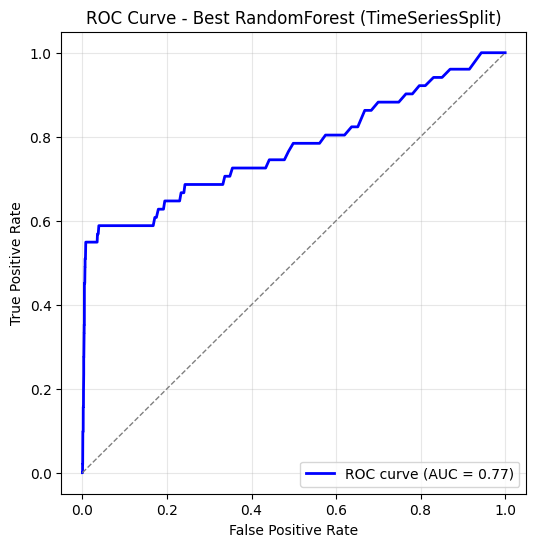

In [22]:
# --- Modelo base ---
rf_clf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=1,
    class_weight="balanced"
)

# --- Espaço de busca de hiperparâmetros ---
param_grid = {
    'n_estimators': [300, 600, 800],
}

# --- Validação cruzada temporal ---
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=rf_clf_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=1,
    verbose=1
)

# --- Treinamento com validação cruzada temporal ---
grid_search.fit(X_features_train_scaled, y_features_train)

print("\nMelhores hiperparâmetros encontrados:")
print(grid_search.best_params_)
print(f"\nMelhor score (F1) na validação cruzada: {grid_search.best_score_:.4f}")

# --- Melhor modelo ---
best_rf_clf = grid_search.best_estimator_

# --- Avaliação no conjunto de teste ---
y_pred_rf = best_rf_clf.predict(X_features_test_scaled)

accuracy = balanced_accuracy_score(y_features_test, y_pred_rf)
f1 = f1_score(y_features_test, y_pred_rf, average='weighted')
recall = recall_score(y_features_test, y_pred_rf, average='weighted')
precision = precision_score(y_features_test, y_pred_rf, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

# --- Curva ROC ---
y_proba_rf = best_rf_clf.predict_proba(X_features_test_scaled)

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_features_test)

if y_test_bin.ndim > 1 and y_test_bin.shape[1] > 1:
    y_scores = y_proba_rf[:, 1]
else:
    y_test_bin = y_test_bin.ravel()
    y_scores = y_proba_rf[:, 1]

fpr, tpr, _ = roc_curve(y_test_bin, y_scores)
roc_auc = roc_auc_score(y_test_bin, y_scores)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best RandomForest (TimeSeriesSplit)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Plot real values and predictions

In [23]:
y_features_test.sort_index(inplace=True)
X_features_test.sort_index(inplace=True)

fig_pred_rf = go.Figure()
fig_pred_rf.add_trace(go.Scatter(
    x = X_features_test.index,
    y=y_pred_rf,
    name='Predict',
    mode="lines",
    line=dict(color='black')
))
fig_pred_rf.add_trace(go.Scatter(
    y=y_features_test,
    x = X_features_test.index,
    name='Real',
    mode="lines",
    line=dict(color='red')
))
fig_pred_rf.update_layout(
    template='plotly_white',
    hovermode='x unified',
    title="RandomForest Predictions vs Real Values"
)
fig_pred_rf.show()

## Proba
y_proba_rf = best_rf_clf.predict_proba(X_features_test_scaled)
y_proba_rf = y_proba_rf[:, 1]

y_features_test.sort_index(inplace=True)
X_features_test.sort_index(inplace=True)

fig_pred_rf = go.Figure()
fig_pred_rf.add_trace(go.Scatter(
    x = X_features_test.index,
    y=y_proba_rf,
    name='Predict',
    mode="lines",
    line=dict(color='black')
))
fig_pred_rf.add_trace(go.Scatter(
    y=y_features_test,
    x = X_features_test.index,
    name='Real',
    mode="lines",
    line=dict(color='red')
))
fig_pred_rf.update_layout(
    template='plotly_white',
    hovermode='x unified',
    title="RandomForest Predictions Proba vs Real Values"
)
fig_pred_rf.show()

## Plot SHAP values of predictions

### Test subset

In [ ]:
start_date = pd.to_datetime("2025-06-16 12:00:00")
end_date = pd.to_datetime("2025-09-17 12:00:00")
mask = (df_dataset[timestamp] >= start_date) & (df_dataset[timestamp] <= end_date)
df_test = df_dataset.loc[mask]
df_test.sort_values(by=[timestamp],inplace=True)

# Parâmetros
window = "60min"
step = "30min"

df_test = df_test.set_index(timestamp)
variables = df_test.drop(columns=["Falhas"])
labels = df_test["Falhas"]

# Constrói as janelas deslizantes
starts = pd.date_range(df_test.index.min(), df_test.index.max() - pd.Timedelta(window), freq=step)

X_list_test, y_list_test, idx_list_test = [], [], []

for start in starts:
    end = start + pd.Timedelta(window)
    window_vars = variables.loc[start:end]
    window_labels = labels.loc[start:end]

    if window_vars.empty or window_labels.empty:
        continue

    # Extrai as features da janela
    feats = features_from_window(window_vars)
    X_list_test.append(feats)

    # Se houver qualquer falha na maior parte da janela, o rótulo é 1, senão 0
    y_list_test.append(int(window_labels.mean() > 0.5))

    # O índice representa o centro da janela
    idx_list_test.append(start + (pd.Timedelta(window) / 2))

# Constrói os DataFrames finais
X_features_test = pd.DataFrame(X_list_test, index=idx_list_test)
y_features_test = pd.Series(y_list_test, index=idx_list_test, name="Falhas")

print("Shape final de X_features_test:", X_features_test.shape)
print("Shape final de y_features_test:", y_features_test.shape)

X_features_test_scaled = pd.DataFrame(scaler.transform(X_features_test), columns=X_features_test.columns, index=X_features_test.index)

In [ ]:
import shap

# === 1. Criar o explicador SHAP
explainer = shap.TreeExplainer(best_rf_clf)

# === 2. Calcular SHAP values (para a classe positiva)
# Se for binário, a terceira dimensão representa as classes [0, 1]
shap_values = explainer.shap_values(X_features_test_scaled)
shap_values_pos = shap_values[:, :, 1]  # classe positiva

# === 3. Gerar gráficos padrão
shap.summary_plot(shap_values_pos, X_features_test_scaled, plot_type="bar")
shap.summary_plot(shap_values_pos, X_features_test_scaled)

# === 4. Extrair importância média absoluta
# Importância média = média do valor absoluto dos shap_values
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)

# === 5. Criar DataFrame ordenado
feature_importance = pd.DataFrame({
    "feature": X_features_test_scaled.columns,
    "importance": mean_abs_shap
}).sort_values(by="importance", ascending=False)

# === 6. Selecionar top N variáveis mais importantes
N = 15  # número de variáveis que deseja analisar
top_features = feature_importance.head(N)
print(top_features)

# === 7. (Opcional) Visualizar em gráfico de barras
plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title(f"Top {N} variáveis mais impactantes segundo SHAP")
plt.xlabel("Importância média (|SHAP|)")
plt.ylabel("Variável")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
feature_name = "762P0034.PV_max"

# === 2. Gerar o gráfico de dependência ===
# - O eixo X mostra o valor da feature.
# - O eixo Y mostra o impacto (SHAP value) na predição.
# - As cores mostram o valor de uma segunda feature interagente automaticamente escolhida.
shap.dependence_plot(
    feature_name,
    shap_values_pos,                # SHAP values da classe positiva
    X_features_test_scaled,         # dataset de entrada
    interaction_index=None,         # SHAP escolhe automaticamente a segunda variável com maior interação
    show=False                      # para customizar o plot antes de mostrar
)

plt.title(f"Efeito de '{feature_name}' na previsão (classe positiva)")
plt.xlabel(f"Valor da variável '{feature_name}'")
plt.ylabel("Valor SHAP (impacto na previsão)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# XGBoost

## Fit model, predict and evaluate RandomSearch

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores hiperparâmetros encontrados:
{'subsample': 0.8, 'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}

Melhor score (F1) na validação cruzada: 0.7782

Resultados no Conjunto de Teste com o Melhor Modelo:
Accuracy: 0.7485
F1 Score: 0.9875
Recall: 0.9841
Precision: 0.9919


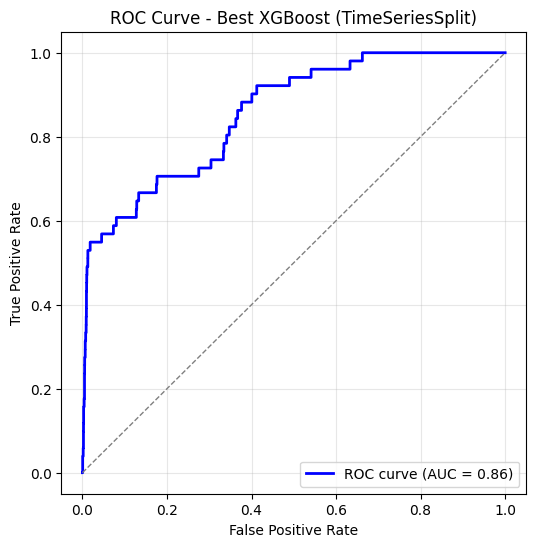

In [24]:
counts = y_features_train.value_counts()
class_weights = counts.get(0, 0) / counts.get(1, 1)
class_weights

# --- Modelo base ---
xgb_clf = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="aucpr",  # pode ser 'logloss' ou 'auc'
    scale_pos_weight=class_weights,
    n_jobs=1
)

# --- Espaço de busca de hiperparâmetros ---
param_dist = {
    'n_estimators': [100, 300, 500, 800, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# --- Validação cruzada temporal ---
tscv = TimeSeriesSplit(n_splits=5)

# --- Busca aleatória de hiperparâmetros ---
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=1,
    verbose=1,
    random_state=42
)

# --- Treinamento com validação temporal ---
random_search.fit(X_features_train_scaled.to_numpy(), y_features_train.to_numpy())

print("\nMelhores hiperparâmetros encontrados:")
print(random_search.best_params_)
print(f"\nMelhor score (F1) na validação cruzada: {random_search.best_score_:.4f}")

# --- Melhor modelo ---
best_xgb_clf = random_search.best_estimator_

# --- Avaliação no conjunto de teste ---
y_pred_xgb = best_xgb_clf.predict(X_features_test_scaled.to_numpy())
y_proba_xgb = best_xgb_clf.predict_proba(X_features_test_scaled.to_numpy())

accuracy = balanced_accuracy_score(y_features_test, y_pred_xgb)
f1 = f1_score(y_features_test, y_pred_xgb, average='weighted')
recall = recall_score(y_features_test, y_pred_xgb, average='weighted')
precision = precision_score(y_features_test, y_pred_xgb, average='weighted')

print(f"\nResultados no Conjunto de Teste com o Melhor Modelo:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

# --- Curva ROC ---
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_features_test.to_numpy()).ravel()
y_scores = y_proba_xgb[:, 1]

fpr, tpr, _ = roc_curve(y_test_bin, y_scores)
roc_auc = roc_auc_score(y_test_bin, y_scores)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best XGBoost (TimeSeriesSplit)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Plot real values and predictions

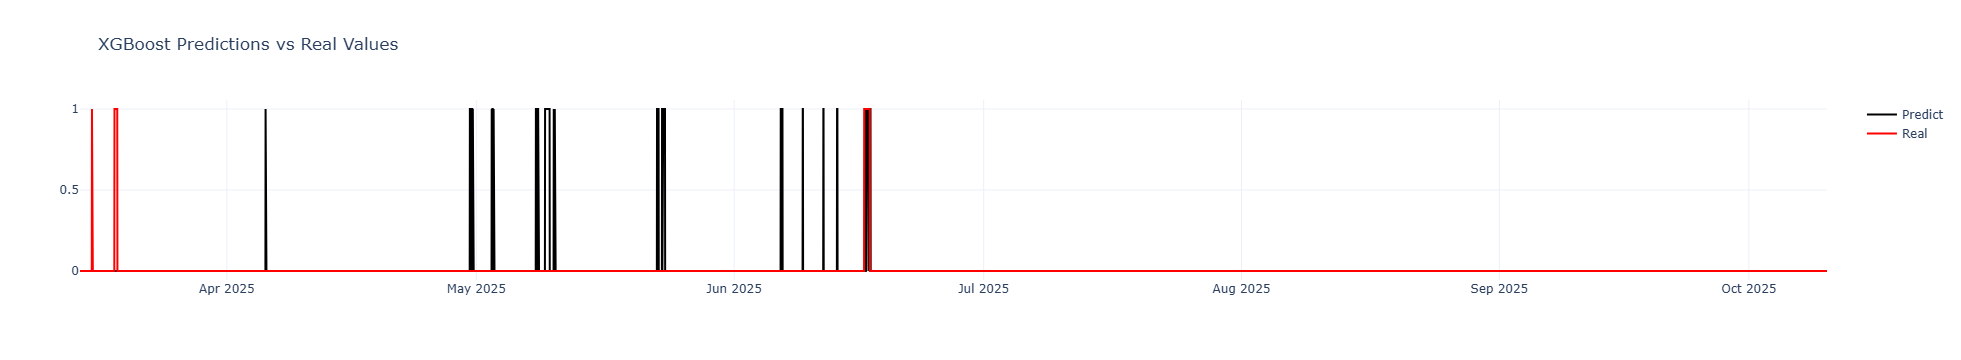

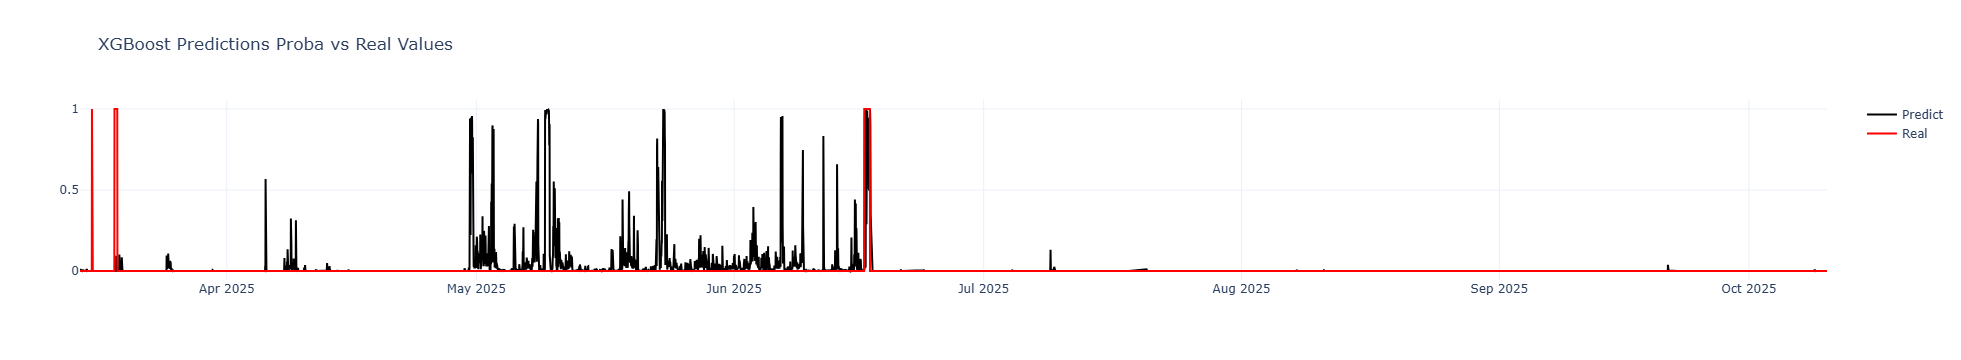

In [26]:
y_features_test.sort_index(inplace=True)
X_features_test.sort_index(inplace=True)

fig_pred_xgb = go.Figure()
fig_pred_xgb.add_trace(go.Scatter(
    x = X_features_test.index,
    y=y_pred_xgb,
    name='Predict',
    mode="lines",
    line=dict(color='black')
))
fig_pred_xgb.add_trace(go.Scatter(
    y=y_features_test,
    x = X_features_test.index,
    name='Real',
    mode="lines",
    line=dict(color='red')
))
fig_pred_xgb.update_layout(
    template='plotly_white',
    hovermode='x unified',
    title="XGBoost Predictions vs Real Values"
)
fig_pred_xgb.show()

## Proba
y_proba_xgb = best_xgb_clf.predict_proba(X_features_test_scaled.to_numpy())
y_proba_xgb = y_proba_xgb[:, 1]

y_features_test.sort_index(inplace=True)
X_features_test.sort_index(inplace=True)

fig_pred_xgb = go.Figure()
fig_pred_xgb.add_trace(go.Scatter(
    x = X_features_test.index,
    y=y_proba_xgb,
    name='Predict',
    mode="lines",
    line=dict(color='black')
))
fig_pred_xgb.add_trace(go.Scatter(
    y=y_features_test,
    x = X_features_test.index,
    name='Real',
    mode="lines",
    line=dict(color='red')
))
fig_pred_xgb.update_layout(
    template='plotly_white',
    hovermode='x unified',
    title="XGBoost Predictions Proba vs Real Values"
)
fig_pred_xgb.show()

## Plot SHAP values of predictions

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_clf)
# Shap values of the test set
shap_values = explainer.shap_values(X_features_test.to_numpy())

# Summary plot mean feature importance
shap.summary_plot(shap_values, X_features_test, plot_type="bar")
# 2. Beeswarm plot impact of each variable on each prediction
shap.summary_plot(shap_values, X_features_test)

# KNN

## Fit model, predict and evaluate

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Melhores hiperparâmetros encontrados:
{'n_neighbors': 19, 'weights': 'distance'}
Melhor F1 na validação cruzada: 0.8242

=== Avaliação do modelo kNN ===
Accuracy:  0.7297
F1 Score:  0.9883
Recall:    0.9856
Precision: 0.9917


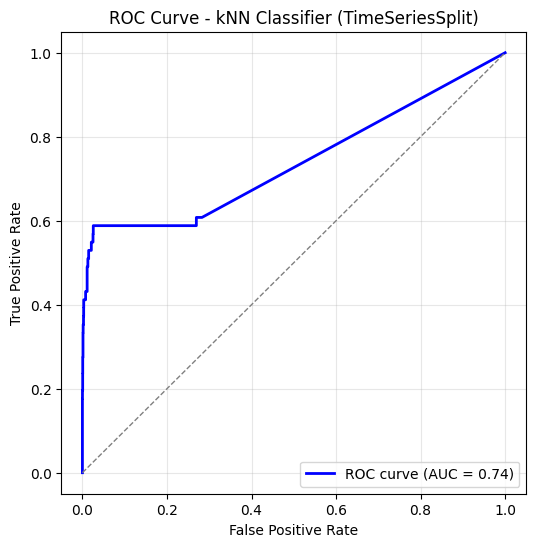

In [20]:
# --- Validação cruzada temporal ---
tscv = TimeSeriesSplit(n_splits=5)  # Divide em 5 blocos temporais, respeitando a ordem

n_neighbors = np.arange(1, 20, 2)
# --- Busca pelo melhor k ---
param_grid = {
    'n_neighbors': n_neighbors.tolist(),
    'weights': ['uniform', 'distance']
}

knn_base = KNeighborsClassifier(
    metric='minkowski',
    p=2,
    n_jobs=1
)

grid_search = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=1,
    verbose=1
)

# Treina apenas com dados passados em cada split (TimeSeriesSplit cuida disso)
grid_search.fit(X_features_train_scaled, y_features_train)

print("\nMelhores hiperparâmetros encontrados:")
print(grid_search.best_params_)
print(f"Melhor F1 na validação cruzada: {grid_search.best_score_:.4f}")

# --- Modelo final treinado com os melhores parâmetros ---
best_knn = grid_search.best_estimator_

# Avaliação no conjunto de teste (mantido como o bloco final)
y_pred_knn = best_knn.predict(X_features_test_scaled)

accuracy = balanced_accuracy_score(y_features_test, y_pred_knn)
f1 = f1_score(y_features_test, y_pred_knn, average='weighted')
recall = recall_score(y_features_test, y_pred_knn, average='weighted')
precision = precision_score(y_features_test, y_pred_knn, average='weighted')

print("\n=== Avaliação do modelo kNN ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")

# --- Curva ROC ---
if hasattr(best_knn, "predict_proba"):
    y_proba_knn = best_knn.predict_proba(X_features_test_scaled)

    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_features_test)

    if y_test_bin.ndim > 1 and y_test_bin.shape[1] > 1:
        y_scores = y_proba_knn[:, 1]
    else:
        y_test_bin = y_test_bin.ravel()
        y_scores = y_proba_knn[:, 1]

    fpr, tpr, _ = roc_curve(y_test_bin, y_scores)
    roc_auc = roc_auc_score(y_test_bin, y_scores)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - kNN Classifier (TimeSeriesSplit)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("O modelo kNN não suporta predict_proba com a configuração atual.")

In [21]:
y_features_test.sort_index(inplace=True)
X_features_test.sort_index(inplace=True)

fig_pred_knn = go.Figure()
fig_pred_knn.add_trace(go.Scatter(
    x = X_features_test.index,
    y=y_pred_knn,
    name='Predict',
    mode="lines",
    line=dict(color='black')
))
fig_pred_knn.add_trace(go.Scatter(
    y=y_features_test,
    x = X_features_test.index,
    name='Real',
    mode="lines",
    line=dict(color='red')
))
fig_pred_knn.update_layout(
    template='plotly_white',
    hovermode='x unified',
    title="kNN Predictions vs Real Values"
)
fig_pred_knn.show()


## Proba
y_proba_knn = best_knn.predict_proba(X_features_test_scaled)
y_proba_knn = y_proba_knn[:, 1]

y_features_test.sort_index(inplace=True)
X_features_test.sort_index(inplace=True)

fig_pred_knn = go.Figure()
fig_pred_knn.add_trace(go.Scatter(
    x = X_features_test.index,
    y=y_proba_knn,
    name='Predict',
    mode="lines",
    line=dict(color='black')
))
fig_pred_knn.add_trace(go.Scatter(
    y=y_features_test,
    x = X_features_test.index,
    name='Real',
    mode="lines",
    line=dict(color='red')
))
fig_pred_knn.update_layout(
    template='plotly_white',
    hovermode='x unified',
    title="kNN Predictions Proba vs Real Values"
)
fig_pred_knn.show()